In [ ]:
#Initiate Packages
from rdkit import Chem
from rdkit.Chem import Draw

<span style="font-size:20px"><b>SMILES Formatting of L-Lysine Using CHUCKLES</b></span>

Youtube Link: https://youtu.be/fYV0Nie_UlQ 

Description: In this example we go over the SMILES CHUCKLE string format of L-Lysine natural amino acid

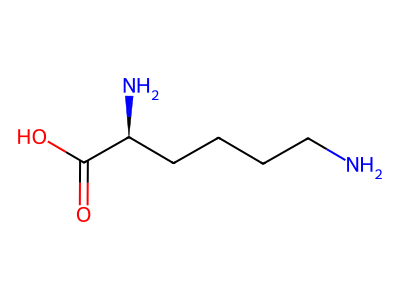

In [13]:
smiles = "N[C@@H](CCCCN)C(=O)O"  

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)


<span style="font-size:20px"><b>SMILES Formatting of L-Methionine Using CHUCKLES</b></span>

Youtube Link: https://youtu.be/aSm2GZzw-n0 

Description: In this example we implement the SMILES CHUCKLE string format of L-Methionine natural amino acid


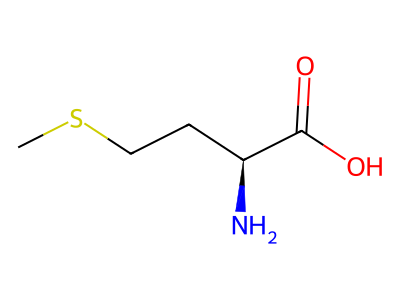

In [14]:
smiles = "N[C@@H](CCSC)C(=O)O"  

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

<span style="font-size:20px"><b>Re-Writing L-VALINE SMILES Notation Using CHUCKLES</b></span>

Youtube Link: https://youtu.be/xSJS_Vi_LqQ

Description: In this example we implement the SMILES CHUCKLE string format of L-Valine natural amino acid


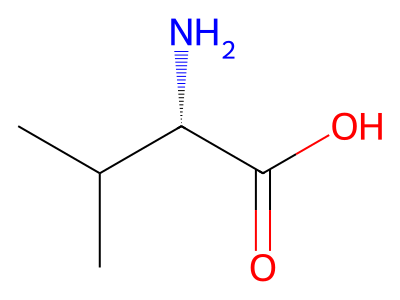

In [15]:
smiles = "N[C@@H](C(C)C)C(=O)O"  

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

<span style="font-size:20px"><b>Writing L-Proline in SMILES Using CHUCKLES</b></span>

Youtube Link: https://youtu.be/w3iozfYYoMM

Description: In this example we implement the SMILES CHUCKLE string format of L-Proline natural amino acid


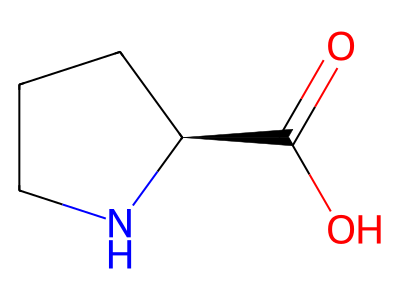

In [16]:
smiles = "N1[C@@H](CCC1)C(=O)O"  

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

<span style="font-size:20px"><b>Introduction to Peptide Bond Formation & String Concatenation</b></span>

Youtube Link: https://youtu.be/hofNBV3Ycr0

Description: In this example we combine two L-Lysine amino acid together using SMILES CHUCKLE string format


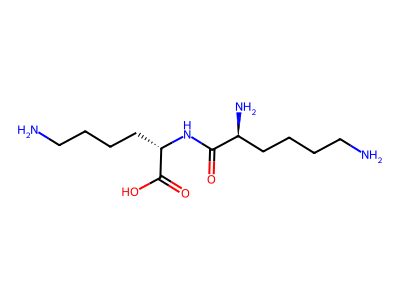

In [17]:
from rdkit import Chem
from rdkit.Chem import Draw

smiles = "[NH2][C@@H](CCCCN)[C](=O)[NH1][C@@H](CCCCN)[C](=O)O"  # L-Lysine

mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("-----SMILES Invalid-----")

img = Draw.MolToImage(mol, size=(400, 300)) 
display(img)

<span style="font-size:20px"><b>Introduction to Mapping Numbers to Track Peptide Bonds</b></span>

Youtube Link: https://youtu.be/8he6qLvxpHg

Description: In this example we introduce mapping numbers using SMILES CHUCKLE string format to keep track of peptide bonds


L-Isoleucine


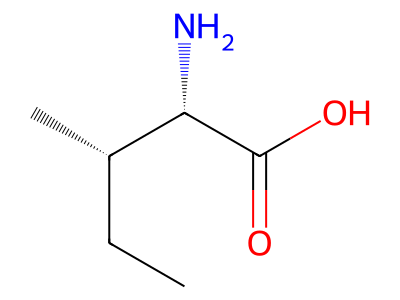

L-Arginine


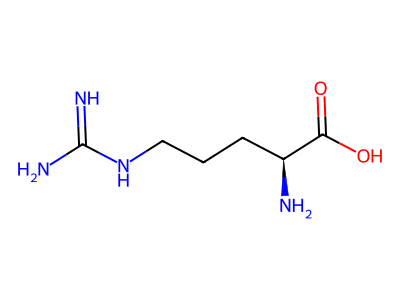

Combination


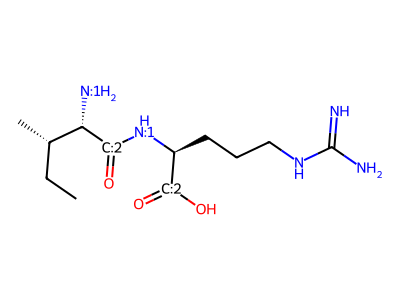

[7]


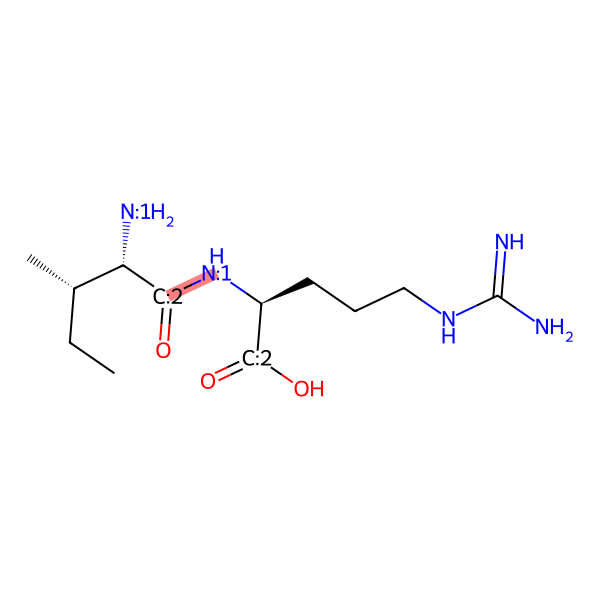

In [18]:
def util_peptide_bonds(mol):
    """
    Identifies peptide bonds in a molecule based on atomMap numbers.
    Peptide bonds are defined as bonds between atoms with atomMap numbers 1 and 2.
    
    Args:
        mol (Chem.Mol): RDKit molecule object.
    
    Returns:
        list: List of bond indices that are identified as peptide bonds.
    
    Raises:
        ValueError: If the molecule does not contain atoms with atomMap numbers 1 or 2.
    """
    # Get atom indices with atomMap numbers 1 and 2 (used to identify peptide bonds)
    atoms_map1 = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomMapNum() == 1]
    atoms_map2 = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomMapNum() == 2]
    
    # Raise error if either list is empty
    if not atoms_map1:
        raise ValueError("No atoms found with atomMapNum 1 in the molecule.")
    if not atoms_map2:
        raise ValueError("No atoms found with atomMapNum 2 in the molecule.")
    
    # Identify bonds connecting atoms from map1 to map2 — i.e., peptide bonds
    peptidic_bonds = []
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if (a1 in atoms_map1 and a2 in atoms_map2) or (a1 in atoms_map2 and a2 in atoms_map1):
            peptidic_bonds.append(bond.GetIdx())
    
    return peptidic_bonds

def util_highlight_peptide_bonds(mol, peptidic_bonds):
    """ 
    Highlights peptide bonds in a molecule by displaying them in a different color.
    
    Args:
        mol (Chem.Mol): RDKit molecule object.
        peptidic_bonds (list): List of bond indices that are peptide bonds.
    Returns:
        None: Displays the molecule with highlighted peptide bonds.
    Raises:
        ValueError: If the list of peptide bonds is empty.
    
    """
    # Raise error if either list is empty
    if not peptidic_bonds:
        raise ValueError("No peptide bonds found to highlight.")
    
    # Optional: highlight identified peptide bonds (cyan color)
    highlight_bond_colors = {idx: (0.0, 1.0, 1.0) for idx in peptidic_bonds}
    
    # Display the molecule with highlighted peptide bonds
    img = Draw.MolToImage(
                        mol,
                        size=(600, 600),
                        highlightBonds=peptidic_bonds,
                        highlightBondColors=highlight_bond_colors
                        )
    display(img)

#Two Natural Amino Acids (L-Isoleucine & L-Arginine)

#L-Isoleucine
smiles_1 = "N[C@@H]([C@@H](C)(CC))C(=O)O" 
#L-Arginine
smiles_2 = "N[C@@H](CCCNC(N)=N)C(=O)O"

mol_1 = Chem.MolFromSmiles(smiles_1)
mol_2 = Chem.MolFromSmiles(smiles_2)

print("L-Isoleucine")
img1 = Draw.MolToImage(mol_1, size=(400, 300)) 
display(img1)

print("L-Arginine")
img2 = Draw.MolToImage(mol_2, size=(400, 300)) 
display(img2)

smiles_combo = "[NH2:1][C@@H]([C@@H](C)(CC))[C:2](=O)[NH1:1][C@@H](CCCNC(N)=N)[C:2](=O)O"
mol_combo = Chem.MolFromSmiles(smiles_combo)

print("Combination")
img_combo = Draw.MolToImage(mol_combo, size=(400, 300)) 
display(img_combo)
peptidic_bond_list = util_peptide_bonds(mol_combo)
print(peptidic_bond_list)
util_highlight_peptide_bonds(mol_combo, peptidic_bond_list)


<span style="font-size:20px"><b>Concatenating Two Non-Canonical Amino Acids</b></span>

Youtube Link: https://youtu.be/AlDvj8n1Cdk

Description: In this example we combine two Non-Canonical amino acid together using SMILES CHUCKLE string format


D-Tryosine


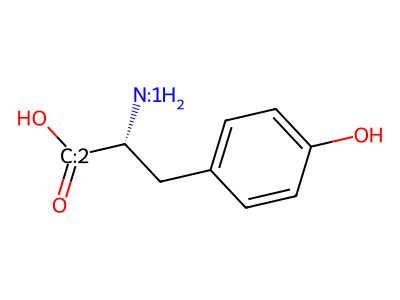

D-Tryosine


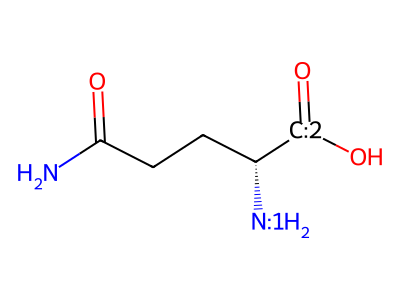

Combination


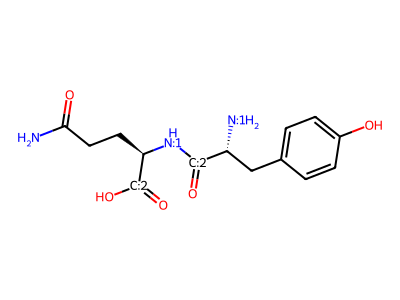

In [19]:
#1st Non-natural Amino Acid: D-Tryosine
smiles_1 = "[NH2:1][C@H](Cc1ccc(O)cc1)[C:2](=O)O"

#2nd Non-natural Amino Acid: D-Glutamine"
smiles_2 = "[NH2:1][C@H](CCC(=O)N)[C:2](=O)O"

#Combination 
smiles_combo = "[NH2:1][C@H](Cc1ccc(O)cc1)[C:2](=O)[NH1:1][C@H](CCC(=O)N)[C:2](=O)O"

mol_1 = Chem.MolFromSmiles(smiles_1)
mol_2 = Chem.MolFromSmiles(smiles_2)
mol_combo = Chem.MolFromSmiles(smiles_combo)

print("D-Tryosine")
img_1 = Draw.MolToImage(mol_1, size = (400,300))
display(img_1)

print("D-Tryosine")
img_2 = Draw.MolToImage(mol_2, size = (400,300))
display(img_2)

print("Combination")
img_combo = Draw.MolToImage(mol_combo, size = (400,300))
display(img_combo)

<span style="font-size:20px"><b>Employing Mapping Numbers Using Non-Canonical Amino Acids</b></span>

Youtube Link: https://youtu.be/1hvI8uFLLq8

Description: In this example we combine two Non-Canonical amino acid together using SMILES CHUCKLE string format and mapping numbers


D-Glutamine


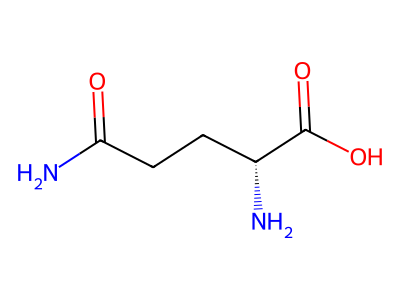

D-Allothreonine


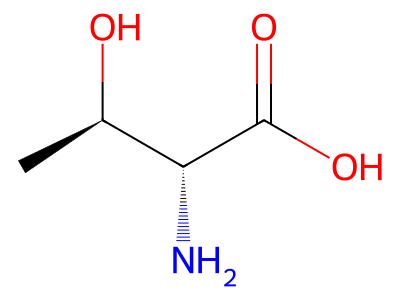

Combination


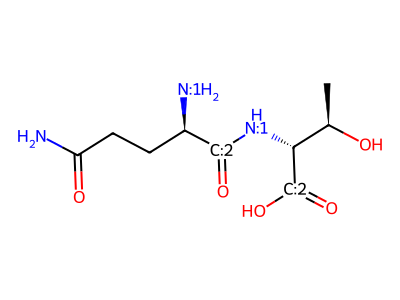

[8]


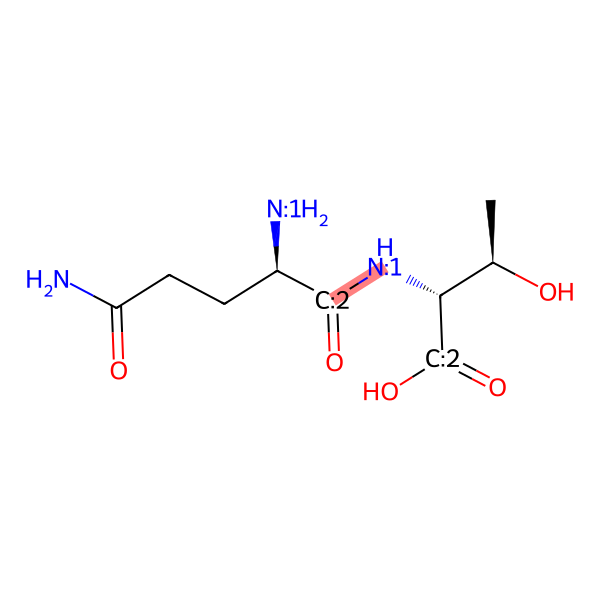

In [ ]:
#Two Non-Natural Amino Acids (D-Glutamine & D-Allothreonine)

#D-Glutamine		
smiles_1 = "N[C@H](CCC(=O)N)C(=O)O"
 
#D-Allothreonine
smiles_2 = "N[C@H]([C@H](O)C)C(=O)O"

mol_1 = Chem.MolFromSmiles(smiles_1)
mol_2 = Chem.MolFromSmiles(smiles_2)

print("D-Glutamine")
img1 = Draw.MolToImage(mol_1, size=(400, 300)) 
display(img1)

print("D-Allothreonine")
img2 = Draw.MolToImage(mol_2, size=(400, 300)) 
display(img2)

smiles_combo = "[NH2:1][C@H](CCC(=O)N)[C:2](=O)[NH1:1][C@H]([C@H](O)C)[C:2](=O)O"
mol_combo = Chem.MolFromSmiles(smiles_combo)
print("Combination")
img_combo = Draw.MolToImage(mol_combo, size=(400, 300)) 
display(img_combo)
peptidic_bond_list = util_peptide_bonds(mol_combo)
print(peptidic_bond_list)
util_highlight_peptide_bonds(mol_combo, peptidic_bond_list)


<span style="font-size:20px"><b> Non-Canonical and Canonical Amino Acid Peptide Ring Formation</b></span>

Youtube Link: https://youtu.be/Z0iK1jwAgPg

Description: In this example we combine two Canonical & two Non-Canonical amino acid together using SMILES CHUCKLE string format and mapping numbers to form a peptide ring

Combination


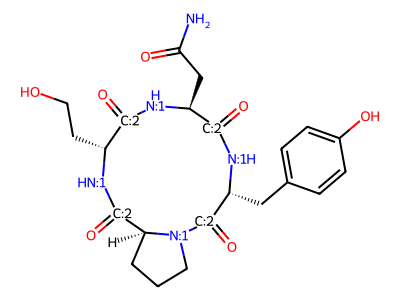

[6, 13, 21, 35]


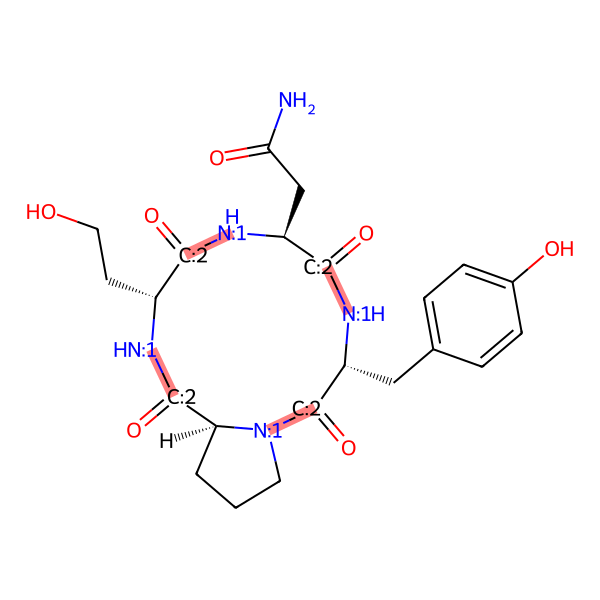

In [21]:
#Natural Amino Acids
#L-Proline - [NH1:1]1CCC[C@H]1[C:2](=O)O
#L-Asparagine - [NH2:1][C@@H](CC(=O)N)[C:2](=O)O


#Non-Natural Amino Acids
#D-homoserine - [NH2:1][C@H](C(CO))[C:2](=O)O
#D-Tyrosine	- [NH2:1][C@H](Cc1ccc(O)cc1)[C:2](=O)O


smiles_combo = "[N:1]51CCC[C@H]1[C:2](=O)[NH1:1][C@H](C(CO))[C:2](=O)[NH1:1][C@@H](CC(=O)N)[C:2](=O)[NH1:1][C@H](Cc1ccc(O)cc1)[C:2]5(=O)"
mol_combo = Chem.MolFromSmiles(smiles_combo)
print("Combination")
img3 = Draw.MolToImage(mol_combo, size=(400, 300)) 
display(img3)
peptidic_bond_list = util_peptide_bonds(mol_combo)
print(peptidic_bond_list)
util_highlight_peptide_bonds(mol_combo, peptidic_bond_list)

<span style="font-size:20px"><b>Non-Canonical and Canonical Amino Acid Peptide Ring Formation</b></span>

Youtube Link: https://youtu.be/IYVM8yTjbf0

Description: In this example we combine four Canonical & four Non-Canonical amino acid together using SMILES CHUCKLE string format and mapping numbers to form a peptide ring

Combination


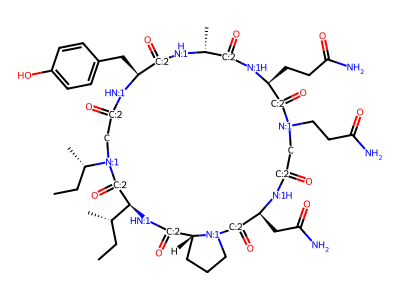

[11, 16, 25, 34, 42, 49, 57, 67]


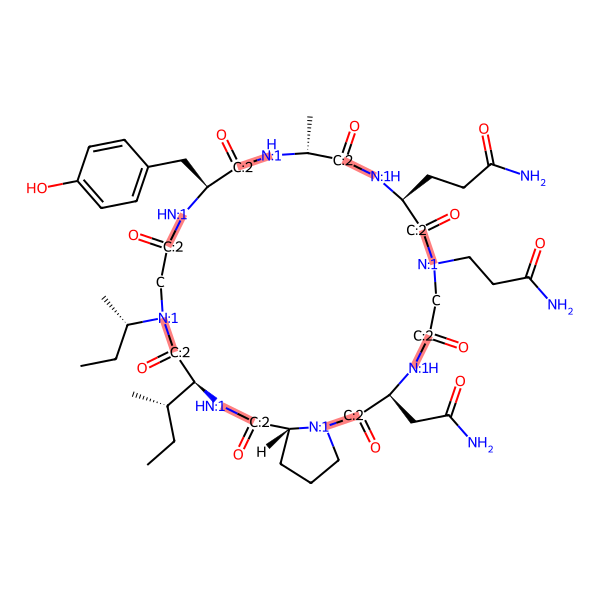

In [ ]:
#Natural Amino Acids
#L-Tyrosine - [NH2:1][C@@H](Cc1ccc(O)cc1)[C:2](=O)O
#L-Glutamine - [NH2:1][C@@H](CCC(=O)N)[C:2](=O)O
#L-Asparagine - [NH2:1][C@@H](CC(=O)N)[C:2](=O)O
#L-Isoleucine - [NH2:1][C@@H]([C@@H](C)(CC))[C:2](=O)O

#Non-Natural Amino Acids
#D-Alanine - [NH2:1][C@H](C)[C:2](=O)O
#N-Glutamine - [NH1:1](CCC(=O)N)C[C:2](=O)O
#D-Proline - [NH1:1]1CCC[C@@H]1[C:2](=O)O
#N-Isoleucine - [NH1:1]([C@@H](C)(CC))C[C:2](=O)O

smiles_combo = "[NH1:1]3[C@@H](Cc1ccc(O)cc1)[C:2](=O)[NH1:1][C@H](C)[C:2](=O)[NH1:1][C@@H](CCC(=O)N)[C:2](=O)[N:1](CCC(=O)N)C[C:2](=O)[NH1:1][C@@H](CC(=O)N)[C:2](=O)[N:1]1CCC[C@@H]1[C:2](=O)[NH1:1][C@@H]([C@@H](C)(CC))[C:2](=O)[N:1]([C@@H](C)(CC))C[C:2]3(=O)"
mol_combo = Chem.MolFromSmiles(smiles_combo)
print("Combination")
img3 = Draw.MolToImage(mol_combo, size=(400, 300)) 
display(img3)
peptidic_bond_list = util_peptide_bonds(mol_combo)
print(peptidic_bond_list)
util_highlight_peptide_bonds(mol_combo, peptidic_bond_list)

## BONUS: Checking Chirality in Molecules Using RDKit (Example: Isoleucine)

This code allows you to visualize a molecule from its SMILES, identify its chiral centers, and check if the assigned chirality matches the expected configuration. It is useful for spotting potential errors in the chirality assignment of amino acids and peptides.

Chirality Concepts

- R/S: absolute configuration of substituents around a chiral carbon.

    - R (rectus) → clockwise orientation.

    - S (sinister) → counterclockwise orientation.

- L/D: relative to glyceraldehyde.

    - Most natural amino acids are L and correspond to S, except for cysteine, which is L but R.

This distinction helps detect assignment errors, e.g., L with R or D with S, which is especially important if you are planning to add a new amino acid and want to ensure the chirality is assigned correctly.

SMILES: [NH2:1][C@H](CCCNC(N)=N)[C:2](=O)O
Chiral centers (atom index, configuration): [(1, 'R')]
----------------------------------------


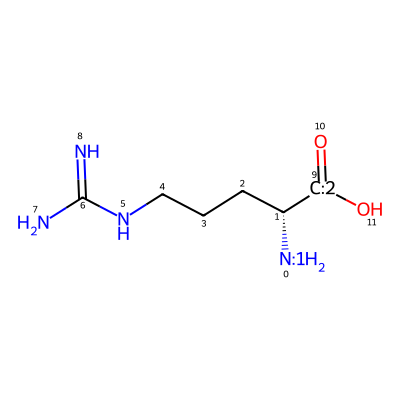

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image
from io import BytesIO
from IPython.display import display

# Define the SMILES of the molecule (example: isoleucine with defined chirality)
smiles = '[NH2:1][C@H](CCCNC(N)=N)[C:2](=O)O'

# Create an RDKit molecule object from the SMILES
mol = Chem.MolFromSmiles(smiles)

# Detect chiral centers in the molecule
# includeUnassigned=True also includes chiral carbons without assigned configuration
chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)

# Display the original SMILES
print(f"SMILES: {smiles}")

# Display the detected chiral centers
if chiral_centers:
    print("Chiral centers (atom index, configuration):", chiral_centers)
else:
    print("No chiral centers found.")
    
print("-"*40)

drawer = Draw.MolDraw2DCairo(400, 400)
drawer.drawOptions().addAtomIndices = True
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
png_data = drawer.GetDrawingText()
img = Image.open(BytesIO(png_data))
display(img)